# Ejecución del factorial — muestra estratificada de 300

**Grupo 2 — Los Predictores** · Proyecto Integrador I · UdeA 2026-2

Corre en local, en un Mac con Apple Silicon (probado en un Mac mini M4). No
necesita tarjeta gráfica dedicada: los modelos corren en la GPU integrada del
chip a través de **MPS**, y el runner la detecta solo (`device: auto`).

Ejecuta las configuraciones de `experiments/configs/` sobre la **misma** muestra
estratificada de 300 artículos del split de test (75 por cuartil de longitud,
semilla 20262) y al final genera todas las métricas: ROUGE-1/2/Lsum,
**BERTScore**, latencia p50/p95, memoria, pruebas pareadas y la recuperación
frente a LED.

| Rol | Configuraciones |
|---|---|
| Factorial (3 × 2) | `truncation`, `map_reduce`, `extractive_abstractive` × BART, PEGASUS |
| Techo (ADR-003) | `baseline_led` |
| Control | `control_longt5_sin_afinar` |
| Piso | `lead_k` |

### Antes de empezar

1. **Kernel.** Abre el notebook con el entorno del proyecto: en VS Code, *Select
   Kernel → `.venv` (Python 3.11)*; o desde la terminal, `uv run jupyter lab`.
   Si el entorno no existe: `make setup`.
2. **Disco.** Hacen falta unos **8 GB libres** para los modelos (sección 2).
3. **Es reanudable.** Cada artículo se escribe en `experiments/results/<config>.jsonl`
   en cuanto termina. Si cierras el notebook, se reinicia el Mac o lo detienes,
   vuelve a ejecutar las celdas: cada configuración continúa donde quedó.
4. **El Mac no debe dormirse.** Cada corrida se lanza con `caffeinate -i`, que
   impide la suspensión mientras dura. La pantalla sí puede apagarse.

## 1. Entorno

In [1]:
import os
import pathlib
import subprocess
import sys

# El notebook vive en notebooks/; los scripts y configuraciones se resuelven
# desde la raíz del repositorio.
RAIZ = pathlib.Path.cwd()
if RAIZ.name == "notebooks":
    RAIZ = RAIZ.parent
os.chdir(RAIZ)

import torch
import resumidor

print("Repositorio:", RAIZ)
print("Python:     ", sys.executable)
print("PyTorch:    ", torch.__version__)
print("MPS:        ", "disponible" if torch.backends.mps.is_available() else "NO disponible — correrá en CPU, mucho más lento")

RESULTADOS = RAIZ / "experiments" / "results"
RESULTADOS.mkdir(parents=True, exist_ok=True)

# Algunas operaciones de LED y LongT5 no tienen kernel en MPS; con esto caen a
# CPU esa operación puntual en vez de abortar la corrida.
ENTORNO = {**os.environ, "PYTORCH_ENABLE_MPS_FALLBACK": "1", "TOKENIZERS_PARALLELISM": "false"}

Repositorio: /Users/carlosforero/UdeA/prointe1/ps1-g2
Python:      /Users/carlosforero/UdeA/prointe1/ps1-g2/.venv/bin/python
PyTorch:     2.14.0
MPS:         disponible


## 2. Espacio en disco

Cada modelo se descarga una vez a `~/.cache/huggingface/`. Si no hay espacio,
la descarga falla a mitad (`No space left on device`) y la configuración
aborta.

Si el disco no alcanza para todos, activa `LIBERAR_MODELOS` en la sección 3:
borra los pesos de cada modelo en cuanto terminan sus configuraciones, así que
solo hay uno en disco a la vez (~2,5 GB de pico, más 1,4 GB de BERTScore al
final). El costo es volver a descargarlo si luego hay que reanudar esa celda.

In [3]:
import shutil

CACHE_HF = pathlib.Path.home() / ".cache" / "huggingface" / "hub"

# Tamaño aproximado de los pesos en disco.
MODELOS_GB = {
    "facebook/bart-large-cnn": 1.6,
    "google/pegasus-arxiv": 2.3,
    "google/long-t5-tglobal-base": 1.0,
    "allenai/led-large-16384-arxiv": 1.8,
    "roberta-large": 1.4,  # BERTScore
}

def carpeta_cache(checkpoint: str) -> pathlib.Path:
    return CACHE_HF / ("models--" + checkpoint.replace("/", "--"))

def descargado(checkpoint: str) -> bool:
    return any(carpeta_cache(checkpoint).glob("snapshots/*/*.safetensors")) or any(
        carpeta_cache(checkpoint).glob("snapshots/*/*.bin"))

libre_gb = shutil.disk_usage(pathlib.Path.home()).free / 1e9
faltan_gb = sum(gb for ck, gb in MODELOS_GB.items() if not descargado(ck))

for ck, gb in MODELOS_GB.items():
    print(f"  {'✓' if descargado(ck) else '·'} {ck:34} {gb:.1f} GB")
print(f"\nLibre: {libre_gb:.1f} GB · por descargar: {faltan_gb:.1f} GB")
if libre_gb < faltan_gb + 1:
    print("\n⚠ No alcanza para todos los modelos. Libera espacio o usa LIBERAR_MODELOS = True.")
if libre_gb < 3.5:
    print("⚠ Ni siquiera alcanza para un modelo a la vez: hay que liberar espacio antes de seguir.")

  ✓ facebook/bart-large-cnn            1.6 GB
  · google/pegasus-arxiv               2.3 GB
  · google/long-t5-tglobal-base        1.0 GB
  · allenai/led-large-16384-arxiv      1.8 GB
  · roberta-large                      1.4 GB

Libre: 43.1 GB · por descargar: 6.5 GB


## 3. Qué correr

Tiempos estimados **en MPS de un M4** para 300 artículos, extrapolados de
corridas cortas. Son órdenes de magnitud: la celda de avance (sección 5)
calcula la cifra real con cada fila escrita.

| Configuración | Invocaciones/doc | Estimación |
|---|---|---|
| `lead_k` | 0 | segundos |
| `truncation_bart` | 1 | ~35 min |
| `extractive_abstractive_bart` | 1 | ~40 min |
| `map_reduce_bart` | ~9 | ~3–4 h |
| `truncation_pegasus`, `extractive_abstractive_pegasus` | 1 | ~2–3 h c/u |
| `map_reduce_pegasus` | ~9 | ~12–15 h |
| `control_longt5_sin_afinar` | 1 (4.096 tokens) | ~6 h |
| `baseline_led` | 1 (16.384 tokens) | varios min/doc; ver `LIMITES` |

El orden va de lo más barato a lo más caro y agrupado por modelo, para tener
resultados comparables cuanto antes y descargar cada modelo una sola vez.

**`LIMITES`** acota el número de documentos de una configuración. La muestra
está barajada, así que los primeros *n* cubren los cuatro estratos. LED está
acotado a 60 por defecto: el ADR-003 admite una muestra menor para la
referencia, que no entra en las pruebas pareadas del factorial, y
`scripts/evaluar.py` lo compara con las demás celdas sobre esos mismos 60
artículos. Pon `None` para los 300.

Para una prueba rápida de punta a punta, usa `PRUEBA = 3`.

In [5]:
CONFIGS = [
    "lead_k",
    "truncation_bart",
    "extractive_abstractive_bart",
    "map_reduce_bart",
    "truncation_pegasus",
    "extractive_abstractive_pegasus",
    "map_reduce_pegasus",
    "control_longt5_sin_afinar",
    "baseline_led",
]
LIMITES = {"baseline_led": 60}   # config -> nº de documentos; ausente = 300
PRUEBA = None                    # p. ej. 3: limita TODAS las configuraciones
LIBERAR_MODELOS = False          # True: borra los pesos al terminar sus celdas

## 4. Ejecución

Cada configuración corre en un proceso aparte: al terminar se libera toda su
memoria antes de cargar el modelo siguiente, lo que importa con 16 GB de
memoria unificada. La salida aparece aquí en vivo.

Puedes interrumpir con ■ en cualquier momento; lo escrito queda guardado.

In [6]:
from resumidor.config import cargar_config

def correr(cfg: str) -> int:
    limite = PRUEBA or LIMITES.get(cfg)
    cmd = ["caffeinate", "-i", sys.executable, "-u", "scripts/run_experiment.py",
           f"experiments/configs/{cfg}.yaml"]
    if limite:
        cmd += ["--limite", str(limite)]
    proceso = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                               text=True, env=ENTORNO, bufsize=1)
    for linea in proceso.stdout:
        # Los avisos de transformers se repiten en cada documento y ahogan el avance.
        if "[transformers]" not in linea and "Warning" not in linea:
            print(linea, end="")
    return proceso.wait()

checkpoints = {c: cargar_config(f"experiments/configs/{c}.yaml").model.checkpoint for c in CONFIGS}

for i, cfg in enumerate(CONFIGS):
    print(f"\n{'═' * 70}\n▶ {cfg}\n{'═' * 70}", flush=True)
    codigo = correr(cfg)
    if codigo != 0:
        print(f"✗ {cfg} terminó con código {codigo}; sigo con la siguiente.")

    ck = checkpoints[cfg]
    if LIBERAR_MODELOS and ck not in (checkpoints[c] for c in CONFIGS[i + 1:]):
        shutil.rmtree(carpeta_cache(ck), ignore_errors=True)
        print(f"🗑 pesos de {ck} liberados")


══════════════════════════════════════════════════════════════════════
▶ lead_k
══════════════════════════════════════════════════════════════════════
Configuración: lead_k
  modelo     facebook/bart-large-cnn
  estrategia lead_k · max_new_tokens=256
  muestra    test · n=300 · estratificado · semilla=20262
  salida     experiments/results/lead_k.jsonl

Cargando modelo y corpus (la primera vez descarga; luego va de caché)...

[1] test-05403 (Q1)  2,002 → 224 tokens  ·  0.0 s  ·  0 invocación(es)
    the main properties of the ultraluminous x - ray sources ( ulxs )   huge luminosities ( @xmath0 ) , diversity of x - ray spectra , strong variability , connection with star - formi...

[2] test-02732 (Q1)  4,505 → 254 tokens  ·  0.0 s  ·  0 invocación(es)
    from the beginning of the development of quantum information theory , it was recognized that without suitable error correcting procedures the fantastic promises of this new discipl...

[3] test-05792 (Q3)  7,407 → 199 tokens  ·  0.0 s

## 5. Avance

In [10]:
import json
import pandas as pd

filas = []
for cfg in CONFIGS:
    f = RESULTADOS / f"{cfg}.jsonl"
    lat = [json.loads(l)["latencia_s"] for l in f.open()] if f.exists() else []
    meta = PRUEBA or LIMITES.get(cfg) or 300
    s_doc = sum(lat) / len(lat) if lat else float("nan")
    filas.append({"config": cfg, "hechos": len(lat), "meta": meta,
                  "s/doc": round(s_doc, 1),
                  "restante_h": round(max(meta - len(lat), 0) * s_doc / 3600, 1)})
avance = pd.DataFrame(filas).set_index("config")
print(f"Restante estimado: {avance['restante_h'].sum():.1f} h (solo cuenta celdas ya iniciadas)")
avance

Restante estimado: 4.7 h (solo cuenta celdas ya iniciadas)


,hechos,meta,s/doc,restante_h
config,,,,
lead_k,300,300,0.0,0.0
truncation_bart,300,300,6.8,0.0
extractive_abstractive_bart,300,300,6.8,0.0
map_reduce_bart,300,300,32.4,0.0
truncation_pegasus,300,300,12.8,0.0
extractive_abstractive_pegasus,300,300,19.3,0.0
map_reduce_pegasus,300,300,57.7,0.0
control_longt5_sin_afinar,300,300,30.5,0.0
baseline_led,30,60,567.8,4.7


## 6. Métricas: ROUGE, BERTScore, costo y pruebas pareadas

`scripts/evaluar.py` califica todas las filas y escribe en
`experiments/results/analisis/`:

- `calificado.csv`: una fila por (configuración, documento) con ROUGE y BERTScore
- `resumen.csv`: calidad y costo por configuración
- `por_estrato.csv`: lo mismo por estrato de longitud (Q1 cortos … Q4 largos)
- `pareadas.csv`: Wilcoxon pareado, IC 95 % bootstrap y corrección de Holm
- `recuperacion.csv`: % del ROUGE-Lsum, latencia y memoria de LED

BERTScore corre en MPS y descarga `roberta-large` la primera vez. Para
~2.700 resúmenes tarda del orden de 10–20 minutos. Se puede ejecutar con
resultados parciales: analiza los documentos comunes al factorial y avisa.

In [13]:
proceso = subprocess.Popen(
    [sys.executable, "scripts/evaluar.py"],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, env=ENTORNO, bufsize=1,
)
for linea in proceso.stdout:
    if "Warning" not in linea:
        print(linea, end="")
print("código de salida:", proceso.wait())

python(10775) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


2430 filas · 9 configuraciones

config_id
baseline_led                       30
control_longt5_sin_afinar         300
extractive_abstractive_bart       300
extractive_abstractive_pegasus    300
lead_k                            300
map_reduce_bart                   300
map_reduce_pegasus                300
truncation_bart                   300
truncation_pegasus                300 

AVISO: 2 resúmenes vacíos.

Calificando (ROUGE + BERTScore)

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 9986.44it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when load

## 7. Lectura

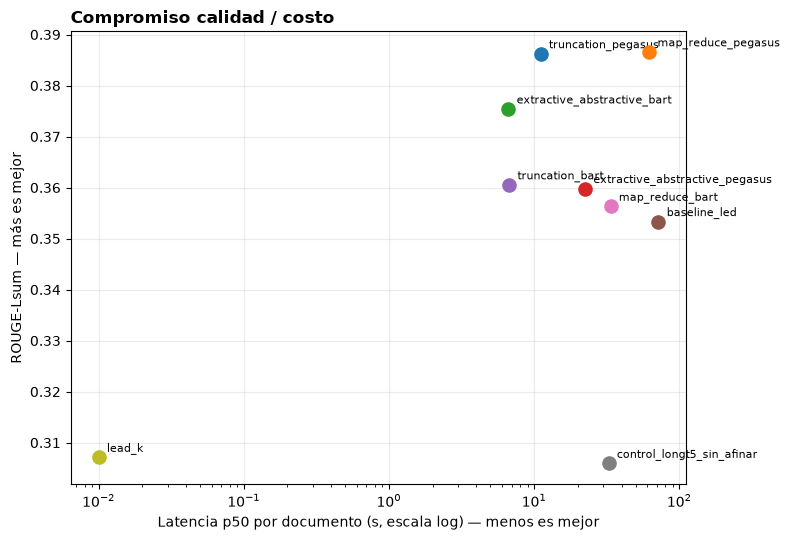

,config_id,modelo,estrategia,n,rouge1,rouge2,rougeLsum,bertscore,latencia_p50,latencia_p95,memoria_pico_mb,ratio_compresion,tokens_generados,invocaciones
0,truncation_pegasus,google/pegasus-arxiv,truncation,300,0.455698,0.170446,0.386229,0.854071,11.0835,22.82135,4220.7,0.038077,210.386667,1.000000
1,map_reduce_pegasus,google/pegasus-arxiv,map_reduce,300,0.448836,0.160362,0.386599,0.852293,61.9645,72.10175,4252.7,0.035165,191.803333,10.246667
2,extractive_abstractive_bart,facebook/bart-large-cnn,extractive_abstractive,300,0.423253,0.137387,0.375396,0.842540,6.6360,7.72745,3148.3,0.029995,161.370000,1.000000
3,extractive_abstractive_pegasus,google/pegasus-arxiv,extractive_abstractive,300,0.420025,0.152552,0.359811,0.845032,22.4080,23.27610,4220.7,0.049775,297.606667,1.000000
4,truncation_bart,facebook/bart-large-cnn,truncation,300,0.404809,0.125872,0.360523,0.839439,6.7295,7.69605,3148.3,0.029724,159.113333,1.000000
5,baseline_led,allenai/led-large-16384-arxiv,truncation,30,0.400066,0.131087,0.353321,0.791379,71.7770,2036.05175,18412.9,0.042614,201.566667,1.000000
6,map_reduce_bart,facebook/bart-large-cnn,map_reduce,300,0.398199,0.116335,0.356318,0.838016,33.5695,46.47095,3172.3,0.030278,162.870000,10.010000
7,control_longt5_sin_afinar,google/long-t5-tglobal-base,truncation,300,0.359913,0.100543,0.305922,0.824759,32.5325,33.81490,3160.3,0.051261,354.806667,1.000000
8,lead_k,facebook/bart-large-cnn,lead_k,300,0.350065,0.090820,0.307099,0.832360,0.0000,0.00000,0.0,0.045753,253.946667,0.000000


In [14]:
import matplotlib.pyplot as plt

A = RESULTADOS / "analisis"
resumen = pd.read_csv(A / "resumen.csv")

fig, ax = plt.subplots(figsize=(8, 5.5))
for _, f in resumen.iterrows():
    x = max(f["latencia_p50"], 0.01)  # lead_k no tiene latencia
    ax.scatter(x, f["rougeLsum"], s=90, zorder=3)
    ax.annotate(f["config_id"], (x, f["rougeLsum"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("Latencia p50 por documento (s, escala log) — menos es mejor")
ax.set_ylabel("ROUGE-Lsum — más es mejor")
ax.set_title("Compromiso calidad / costo", loc="left", fontweight="bold")
ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

resumen

In [15]:
# ¿Dónde gana cada estrategia? Q4 son los artículos más largos, donde el
# truncamiento descarta más.
por_estrato = pd.read_csv(A / "por_estrato.csv")
por_estrato.pivot_table(index="config_id", columns="estrato", values="rougeLsum")

estrato,Q1,Q2,Q3,Q4
config_id,,,,
baseline_led,0.389889,0.375482,0.355999,0.317391
control_longt5_sin_afinar,0.296931,0.298398,0.304824,0.323534
extractive_abstractive_bart,0.362610,0.375305,0.391367,0.372303
extractive_abstractive_pegasus,0.362532,0.368613,0.357100,0.350998
lead_k,0.292268,0.304659,0.317954,0.313513
map_reduce_bart,0.357352,0.358902,0.359484,0.349534
map_reduce_pegasus,0.374800,0.387574,0.396984,0.387036
truncation_bart,0.350566,0.367269,0.361234,0.363024
truncation_pegasus,0.367047,0.384233,0.397129,0.396505


In [16]:
pd.read_csv(A / "pareadas.csv").query("metrica == 'rougeLsum'")

,a,b,metrica,n,media_a,media_b,diferencia,ic95_bajo,ic95_alto,gana_a,p_wilcoxon,p_holm,significativo
0,map_reduce_bart,truncation_bart,rougeLsum,300,0.356318,0.360523,-0.004205,-0.012095,0.003768,0.466667,3.640204e-01,1.000000e+00,False
3,extractive_abstractive_bart,truncation_bart,rougeLsum,300,0.375396,0.360523,0.014873,0.006364,0.023342,0.590000,1.749962e-04,2.624943e-03,True
6,map_reduce_bart,extractive_abstractive_bart,rougeLsum,300,0.356318,0.375396,-0.019079,-0.026953,-0.010975,0.396667,2.091275e-05,3.555167e-04,True
9,map_reduce_pegasus,truncation_pegasus,rougeLsum,300,0.386599,0.386229,0.000370,-0.007055,0.007657,0.490000,5.787166e-01,1.000000e+00,False
12,extractive_abstractive_pegasus,truncation_pegasus,rougeLsum,300,0.359811,0.386229,-0.026418,-0.036207,-0.017080,0.370000,5.008470e-07,9.516093e-06,True
15,map_reduce_pegasus,extractive_abstractive_pegasus,rougeLsum,300,0.386599,0.359811,0.026788,0.017495,0.036070,0.646667,1.437977e-08,3.307347e-07,True
18,baseline_led,lead_k,rougeLsum,30,0.353321,0.306102,0.047219,0.000760,0.090654,0.866667,4.601069e-04,5.521283e-03,True
21,control_longt5_sin_afinar,lead_k,rougeLsum,300,0.305922,0.307099,-0.001177,-0.010870,0.008328,0.520000,8.113099e-01,1.000000e+00,False
24,extractive_abstractive_bart,lead_k,rougeLsum,300,0.375396,0.307099,0.068298,0.059540,0.077302,0.830000,5.567734e-33,1.948707e-31,True
27,extractive_abstractive_pegasus,lead_k,rougeLsum,300,0.359811,0.307099,0.052712,0.043264,0.062058,0.730000,2.144790e-21,6.434369e-20,True


In [17]:
pd.read_csv(A / "recuperacion.csv")

,config_id,rougeLsum_pct,latencia_p50_pct,memoria_pct
0,truncation_pegasus,115.617740,14.454491,22.922516
1,extractive_abstractive_bart,114.413853,9.652117,17.098339
2,map_reduce_pegasus,111.493907,88.455215,23.096307
3,map_reduce_bart,105.817055,50.835922,17.185234
4,truncation_bart,104.799393,9.393678,17.098339
5,extractive_abstractive_pegasus,103.692536,31.008540,22.879068
6,baseline_led,100.000000,100.000000,100.000000
7,control_longt5_sin_afinar,88.034498,45.421932,17.101597
8,lead_k,86.635690,0.000000,0.000000
